In [1]:
"""
Ein einfacher 1D-1V Vlasov-Poisson Solver mit linearem Dämpfungsterm -lambda * f.
Strang-Splitting + semi-Lagrangian (linear interpolation).
Mehrere Vereinfachungen, aber vollständig und didaktisch.
"""
import numpy as np
from numpy.fft import fft, ifft, fftfreq
import matplotlib.pyplot as plt

In [2]:
# ---------- Parameter ----------
Nx = 128            # Gitterpunkte in x (periodisch)
Nv = 201            # Gitterpunkte in v
Lx = 2*np.pi        # Periodenlänge in x
Vmax = 6.0          # v in [-Vmax, Vmax]
dt = 0.1            # Zeitschritt
Tfinal = 50.0       # Endzeit
lam = 0.02          # Dämpfungsrate lambda (term -lambda * f)
plot_interval = 50  # alle wieviel Schritte plotten

In [3]:
# ---------- Gitter und initialisierung ----------
x = np.linspace(0, Lx, Nx, endpoint=False)
v = np.linspace(-Vmax, Vmax, Nv)
dx = x[1] - x[0]
dv = v[1] - v[0]
X, V = np.meshgrid(x, v, indexing='xy')  # shape (Nv, Nx) -> rows: v, cols: x

In [4]:
# Startverteilung: Maxwellian + kleine cos-Störung (klassisches Landau-Dämpfungs-setup)
v_th = 1.0
f0 = (1/np.sqrt(2*np.pi*v_th**2)) * np.exp(-V**2/(2*v_th**2))
alpha = 0.05
f = f0 * (1 + alpha * np.cos(X / (Lx/(2*np.pi))))  # kleine Störung in x

In [5]:
# Normierungscheck: Gesamtladung per x sollte ~1 (neutral Hintergrund)
# Wir take background density = 1 so rho = \int f dv
# ---------- Hilfsfunktionen ----------

def compute_E_from_f(f):
    """
    Berechne elektrisches Feld E(x) aus f(v,x):
    Poisson: dE/dx = rho(x) - 1  (Hintergrundladungsdichte = 1)
    Periodisch -> Fouriersolver:
        ik E_k = rho_k  => E_k = rho_k / (i k), k!=0
    """
    # rho(x) = \int f dv
    rho = np.sum(f, axis=0) * dv
    rho_mean = np.mean(rho)
    rho_tilde = rho - rho_mean  # source term with zero mean

    # Fourier transform
    rho_k = fft(rho_tilde)
    k = 2*np.pi * fftfreq(Nx, d=dx)
    E_k = np.zeros_like(rho_k, dtype=complex)
    # avoid k=0 division
    nonzero = k != 0
    E_k[nonzero] = rho_k[nonzero] / (1j * k[nonzero])
    # set mean mode to zero (E average can be set arbitrarily; take 0)
    E = np.real(ifft(E_k))
    return E, rho

def shift_in_x(f, shift):
    """
    semi-Lagrangian in x: f(x,v) <- f(x - shift, v)
    shift can be array over x (e.g. dt * v for each v)
    We perform for each v a 1D interpolation in x with periodic BC.
    f shape: (Nv, Nx)
    """
    out = np.empty_like(f)
    xs = x  # grid points in x
    for j in range(f.shape[0]):  # loop über v
        src = (xs - shift[j]) % Lx
        # np.interp needs ascending x and returns at xp -> use xs as xp
        out[j, :] = np.interp(xs, xs, f[j, :], period=Lx)  # fallback to periodic interp
        # Above line is naive; better to use np.interp with explicit source positions:
        out[j, :] = np.interp(xs, src, f[j, :], period=Lx)
    return out

def shift_in_v(f, shift_v):
    """
    semi-Lagrangian in v: f(x,v) <- f(x, v - shift_v(x))
    For each x do 1D interpolation in v. For v-boundary use zeros (outflow).
    shift_v shape: (Nx,) or scalar
    f shape: (Nv, Nx)
    """
    out = np.empty_like(f)
    for i in range(f.shape[1]):  # loop über x
        src_v = v - shift_v[i]
        # outside v-grid: set f=0 (simple choice). Use np.interp with left/right=0.
        out[:, i] = np.interp(v, src_v, f[:, i], left=0.0, right=0.0)
    return out

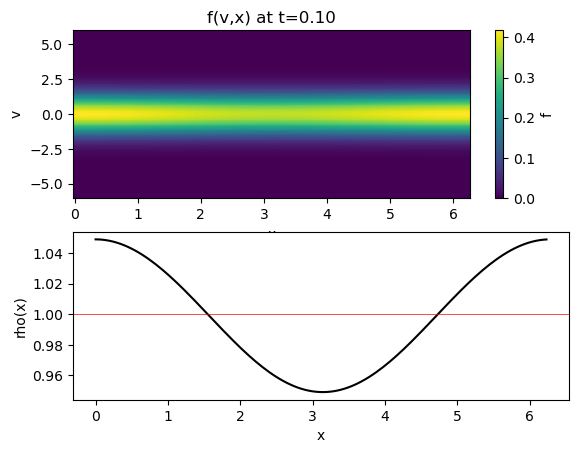

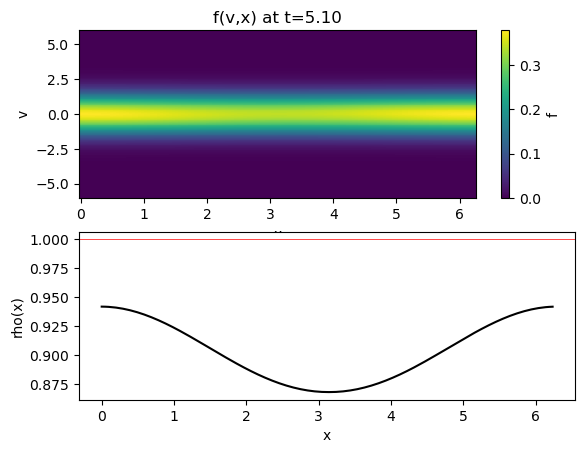

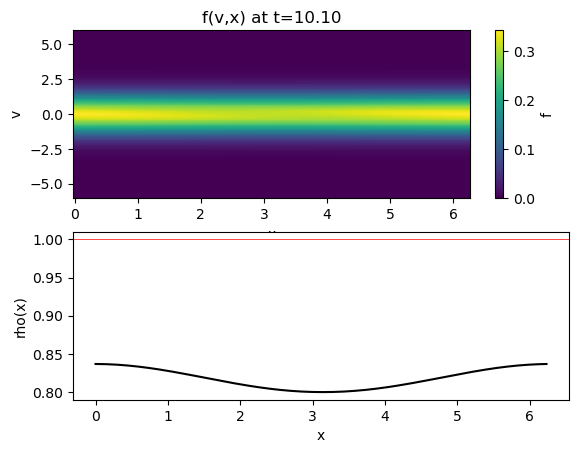

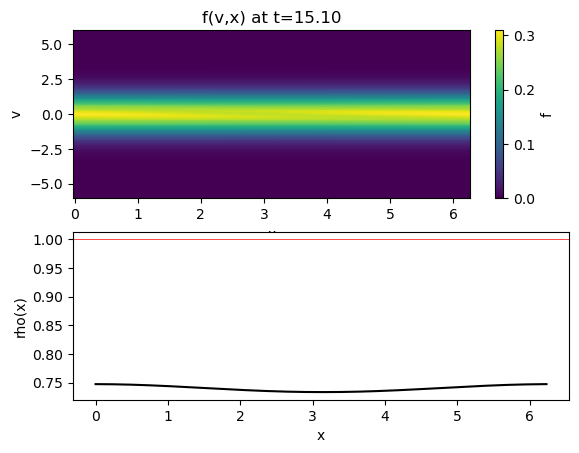

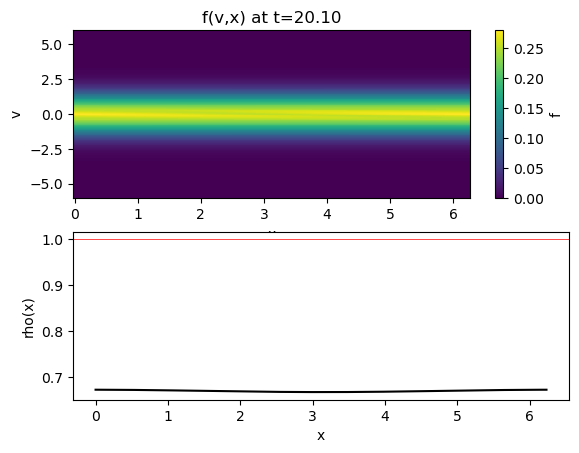

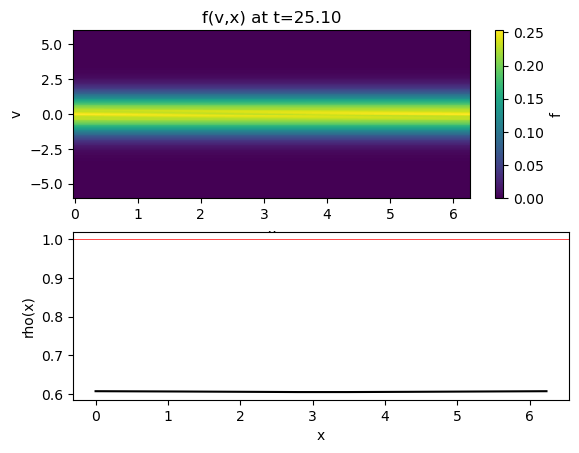

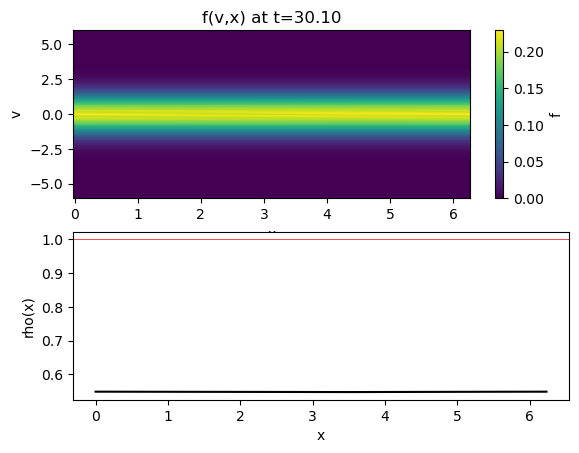

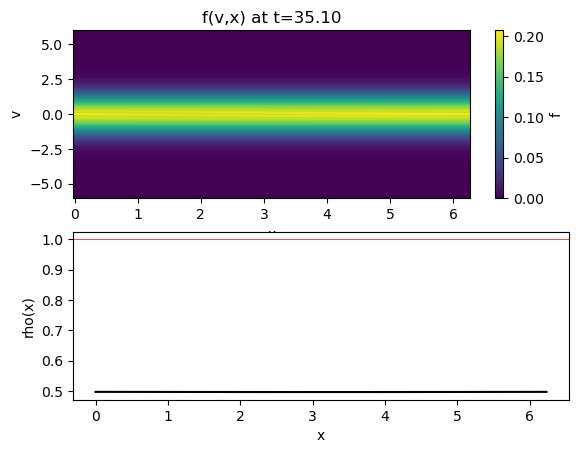

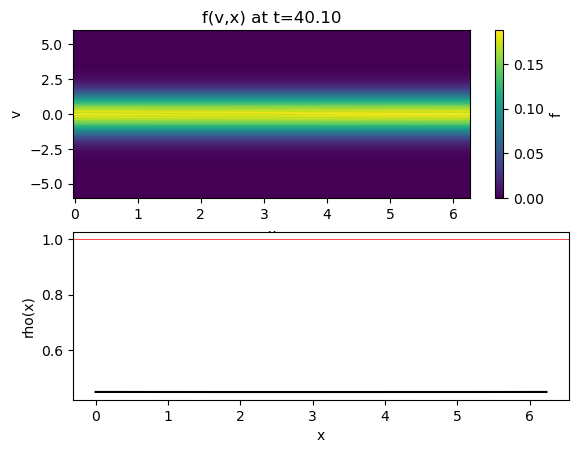

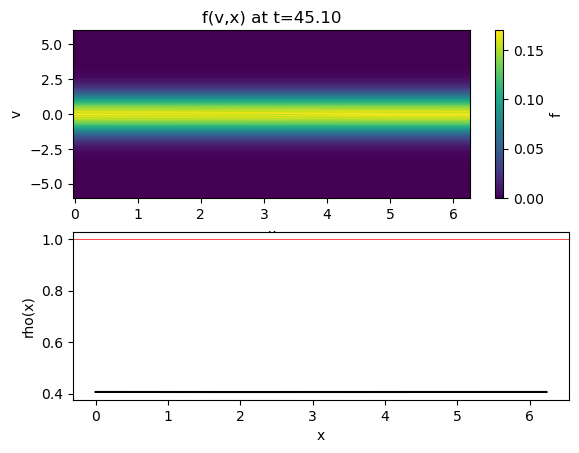

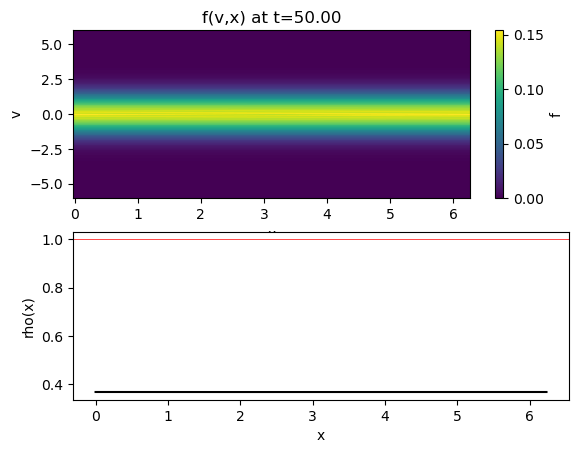

In [6]:
# ---------- Zeitintegration (Strang) ----------
nt = int(np.ceil(Tfinal / dt))
t = 0.0

# optional: Statistik aufzeichnen
time_hist = []
E_energy = []

for n in range(nt):
    # 1) halber v-Schritt: v <- v + (dt/2) * E(x)
    E, rho = compute_E_from_f(f)
    # shift in v is + (dt/2) * E(x) because characteristic: dv/dt = E(x)
    shift_v_half = -0.5 * dt * E  # negative because we do semi-Lagrange f(v) = f_old(v - dt*E)
    f = shift_in_v(f, shift_v_half)

    # Dämpfung exakt für halben Schritt: df/dt = -lambda f -> f *= exp(-lambda * dt/2)
    f *= np.exp(-lam * dt/2)

    # 2) voller x-Schritt: x <- x + dt * v
    # For each v-level shift is dt * v[j]
    shift_x = dt * V[:, 0]  # V[:,0] equals v for each row
    f = shift_in_x(f, shift_x)

    # 3) re-kompute E für zweiten halben v-step
    E, rho = compute_E_from_f(f)
    shift_v_half = -0.5 * dt * E
    f = shift_in_v(f, shift_v_half)

    # Dämpfung für zweiten halben Schritt
    f *= np.exp(-lam * dt/2)

    t += dt

    # statistik
    time_hist.append(t)
    E_energy.append(0.5 * np.sum(E**2) * dx)  # elektrische Energie ~ integral 0.5 E^2 dx

    # plotting alle paar Schritte
    if (n % plot_interval) == 0 or n == nt-1:
        plt.clf()
        plt.subplot(2,1,1)
        plt.pcolormesh(x, v, f, shading='auto')
        plt.xlabel('x'); plt.ylabel('v'); plt.title(f'f(v,x) at t={t:.2f}')
        plt.colorbar(label='f')
        plt.subplot(2,1,2)
        plt.plot(x, rho, '-k')
        plt.axhline(1.0, color='r', linewidth=0.5)
        plt.xlabel('x'); plt.ylabel('rho(x)')
        plt.pause(0.001)

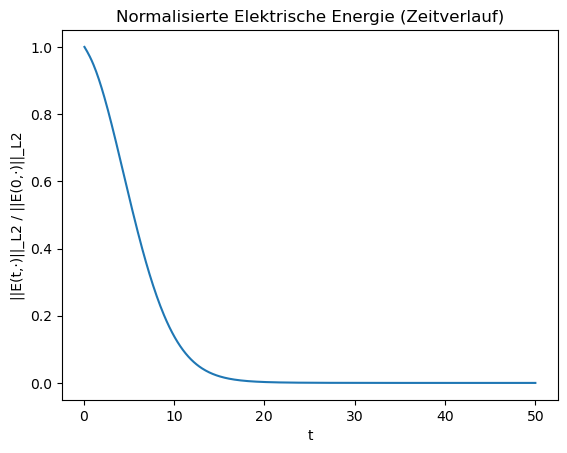

In [8]:
# Endzeit: plot Energiezeitreihe
plt.figure()
plt.plot(time_hist, E_energy / E_energy[0])
plt.xlabel('t'); plt.ylabel('||E(t,⋅)||_L2 / ||E(0,⋅)||_L2')
plt.title('Normalisierte Elektrische Energie (Zeitverlauf)')
plt.show()